In [ ]:
import torch
import torch.nn.functional as F
import torchaudio
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# ======================
# 设备配置
# ======================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ======================
# 加载模型
# ======================
processor = WhisperProcessor.from_pretrained("openai/whisper-tiny.en")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny.en").to(device)
model.eval()

# ======================
# 加载音频
# ======================
waveform, sr = torchaudio.load("jfk.flac")
if sr != 16000:
    waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)
waveform = waveform.to(device)

# ======================
# 目标文本（真实转录，用于计算损失方向）
# ======================
target_text = "And so my fellow Americans ask not what your country can do for you"

# ======================
# 提取 input_features 并设为可求梯度
# ======================
input_features = processor(
    waveform.squeeze(0).cpu().numpy(),
    sampling_rate=16000,
    return_tensors="pt"
).input_features.to(device)

input_features = input_features.detach().requires_grad_(True)

# ======================
# 处理 labels（关键修正:用 processor.tokenizer）
# ======================
labels = processor.tokenizer(target_text, return_tensors="pt").input_ids.to(device)

# ======================
# 前向传播 + 计算损失
# ======================
outputs = model(input_features=input_features, labels=labels)
loss = outputs.loss
print(f"Loss before attack: {loss.item():.4f}")

# ======================
# 反向传播求梯度
# ======================
loss.backward()

# ======================
# FGSM 攻击
# ======================
epsilon = 0.01   # 先用大一点的值,看到效果再调小
data_grad = input_features.grad.data
perturbed_input = input_features + epsilon * torch.sign(data_grad)
perturbed_input = perturbed_input.detach()

# ======================
# 测试结果
# ======================
with torch.no_grad():
    # 原始识别
    pred_clean = model.generate(input_features.detach())
    text_clean = processor.batch_decode(pred_clean, skip_special_tokens=True)[0]

    # 对抗样本识别
    pred_adv = model.generate(perturbed_input)
    text_adv = processor.batch_decode(pred_adv, skip_special_tokens=True)[0]

print("\n" + "="*60)
print(f"epsilon = {epsilon}")
print("="*60)
print(f"原始识别: {text_clean}")
print(f"攻击后识别: {text_adv}")
print(f"攻击是否成功: {'✓' if text_clean != text_adv else '✗'}")

Using device: cuda


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Loss before attack: 2.1073

epsilon = 0.05
原始识别:  And so my fellow Americans ask not what your country can do for you, ask what you can do for your country.
攻击后识别:  And so am I fellow America's......ass enough! Like your country can do for you! Ask like you can do for your country!
攻击是否成功: ✓


In [ ]:
# 看具体差异
print("="*60)
print(f"原始 ({len(text_clean.split())} words):")
print(f"  {text_clean}")
print(f"\n攻击后 ({len(text_adv.split())} words):")
print(f"  {text_adv}")

# 简单WER计算
def simple_wer(ref, hyp):
    ref_words = ref.lower().strip().split()
    hyp_words = hyp.lower().strip().split()
    if len(ref_words) == 0:
        return 0.0
    # 逐位置比较+长度差
    errors = sum(1 for r, h in zip(ref_words, hyp_words) if r != h)
    errors += abs(len(ref_words) - len(hyp_words))
    return errors / len(ref_words)

wer = simple_wer(text_clean, text_adv)
print(f"\n词错误率 (WER): {wer:.1%}")

原始 (22 words):
   And so my fellow Americans ask not what your country can do for you, ask what you can do for your country.

攻击后 (22 words):
   And so am I fellow America's......ass enough! Like your country can do for you! Ask like you can do for your country!

词错误率 (WER): 40.9%


In [ ]:
!pip install -q jiwer

In [ ]:
from jiwer import wer as compute_wer

def standard_wer(ref, hyp):
    """标准 WER,基于 Levenshtein 距离,裁剪到 [0, 1]"""
    # 简单清理:去掉标点、转小写
    import string
    def clean(text):
        text = text.lower().strip()
        text = text.translate(str.maketrans('', '', string.punctuation))
        return text

    ref_clean = clean(ref)
    hyp_clean = clean(hyp)

    if len(ref_clean.split()) == 0:
        return 0.0

    w = compute_wer(ref_clean, hyp_clean)
    return min(w, 1.0)  # 裁剪到 100%

ε=0.000 | WER=0.0% |  And so my fellow Americans ask not what your country can do for you, ask what you can do for your country.
ε=0.001 | WER=0.0% |  And so my fellow Americans ask not what your country can do for you, ask what you can do for your country.
ε=0.005 | WER=0.0% |  And so my fellow Americans ask not what your country can do for you. Ask what you can do for your country.
ε=0.010 | WER=9.1% |  And so am I fellow Americans. Ask not what your country can do for you. Ask what you can do for your country.
ε=0.050 | WER=31.8% |  And so am I fellow America's......ass enough! Like your country can do for you! Ask like you can do for your country!
ε=0.100 | WER=81.8% |  And so all night I fell all America. They asked, like you are a play-pree-kinder for you. They asked like you and you for your country.
ε=0.300 | WER=100.0% |  I'm going to go to the next one.
ε=0.500 | WER=100.0% |  Okay, okay, okay, okay, okay, okay, okay, okay, okay, okay, okay, okay, okay, okay, okay, okay, okay

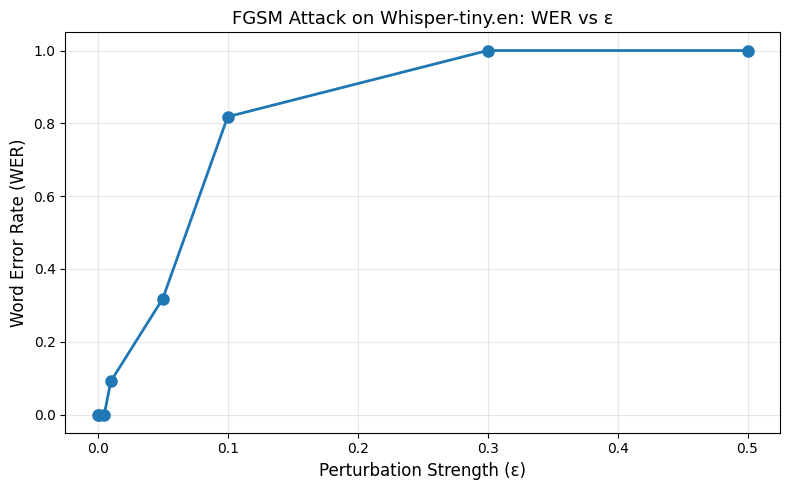


图片已保存为 wer_curve.png


In [ ]:
import matplotlib.pyplot as plt

# epsilon 扫描列表
epsilons = [0.0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5]
results = []


for eps in epsilons:
    # 生成对抗样本
    perturbed = input_features.detach() + eps * torch.sign(data_grad)

    # 识别
    with torch.no_grad():
        pred = model.generate(perturbed)
        text = processor.batch_decode(pred, skip_special_tokens=True)[0]

    # 计算 WER
    wer = standard_wer(text_clean, text)

    results.append({
        'epsilon': eps,
        'text': text,
        'wer': wer
    })

    print(f"ε={eps:.3f} | WER={wer:.1%} | {text[:150]}")

# 画图
plt.figure(figsize=(8, 5))
eps_list = [r['epsilon'] for r in results]
wer_list = [r['wer'] for r in results]

plt.plot(eps_list, wer_list, 'o-', linewidth=2, markersize=8)
plt.xlabel('Perturbation Strength (ε)', fontsize=12)
plt.ylabel('Word Error Rate (WER)', fontsize=12)
plt.title('FGSM Attack on Whisper-tiny.en: WER vs ε', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wer_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n图片已保存为 wer_curve.png")

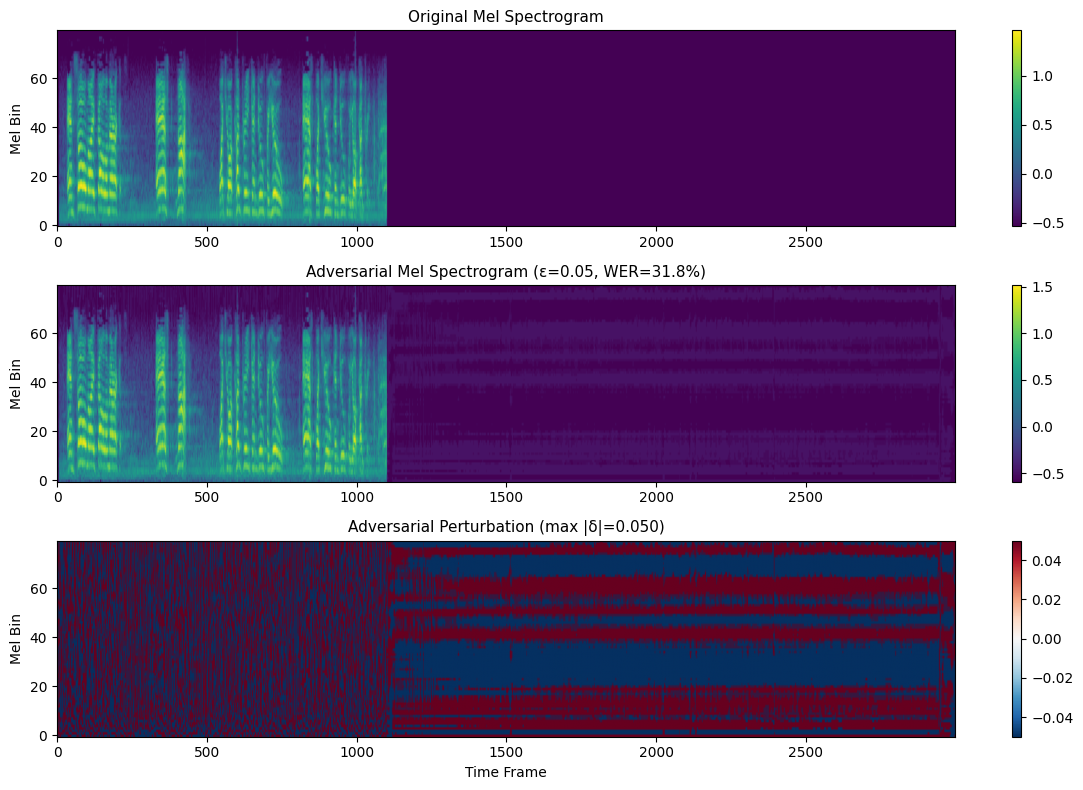

In [ ]:
import numpy as np

# 重新跑一次 ε=0.05 拿到对抗样本

clean_spec = input_features.detach().cpu().numpy()[0]
adv_spec = perturbed_input.cpu().numpy()[0]
perturbation = adv_spec - clean_spec

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

im0 = axes[0].imshow(clean_spec, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original Mel Spectrogram', fontsize=11)
axes[0].set_ylabel('Mel Bin')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(adv_spec, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title(f'Adversarial Mel Spectrogram (ε=0.05, WER=31.8%)', fontsize=11)
axes[1].set_ylabel('Mel Bin')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(perturbation, aspect='auto', origin='lower',
                     cmap='RdBu_r', vmin=-0.05, vmax=0.05)
axes[2].set_title(f'Adversarial Perturbation (max |δ|={np.abs(perturbation).max():.3f})', fontsize=11)
axes[2].set_xlabel('Time Frame')
axes[2].set_ylabel('Mel Bin')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('spectrogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()